# Validation Plots for Backfilled Dataset

This notebook generates validation charts to ensure the structural integrity of the variables, showing English descriptions and original codes for categorical data.


Loading ../data/ukhls/pickles/o_indresp_backfilled.pkl...
Dataset shape: (47354, 42)
Found 31 categorical variables and 10 continuous variables.



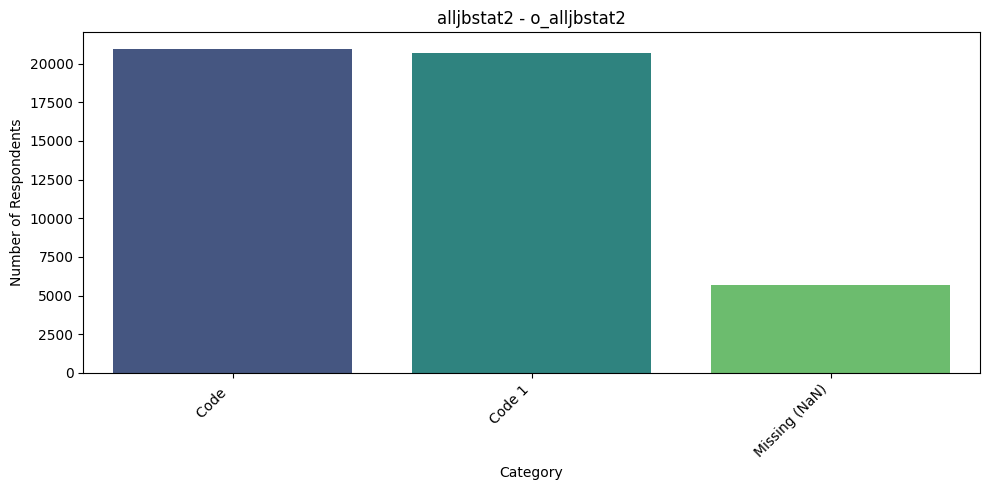

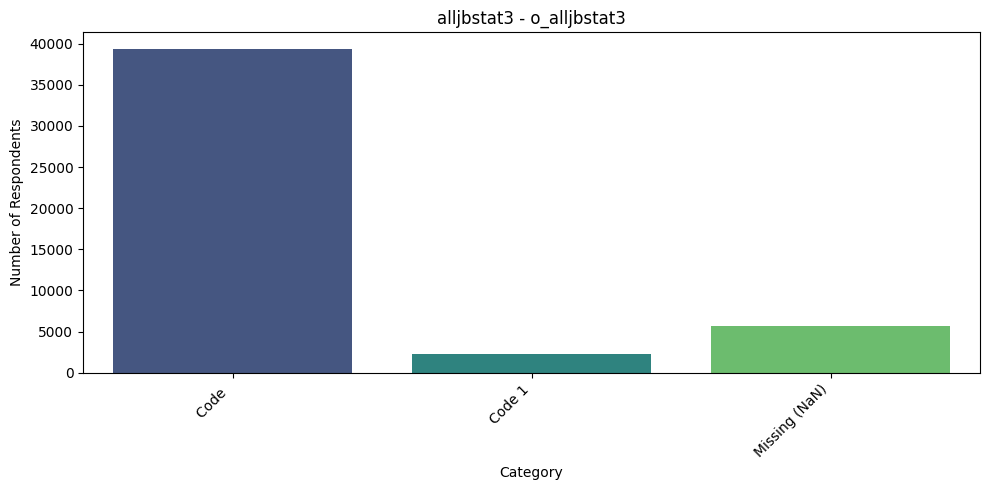

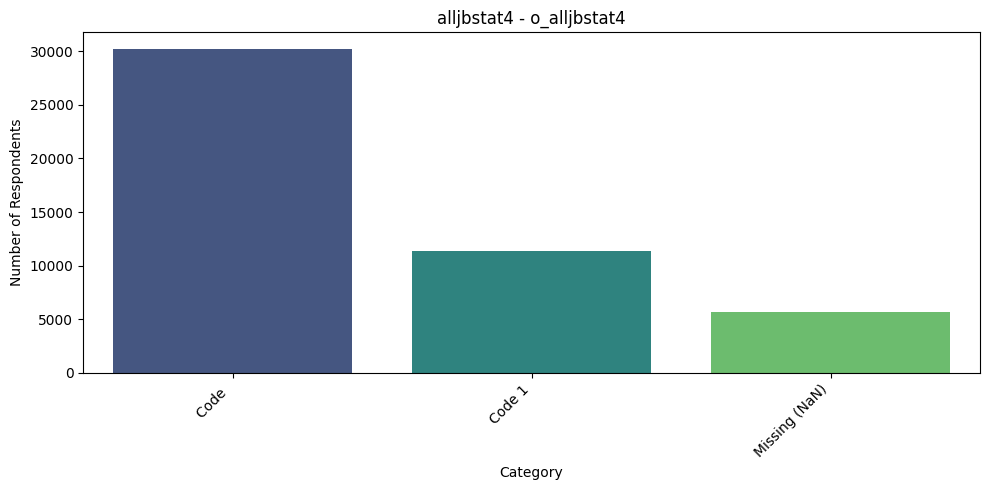

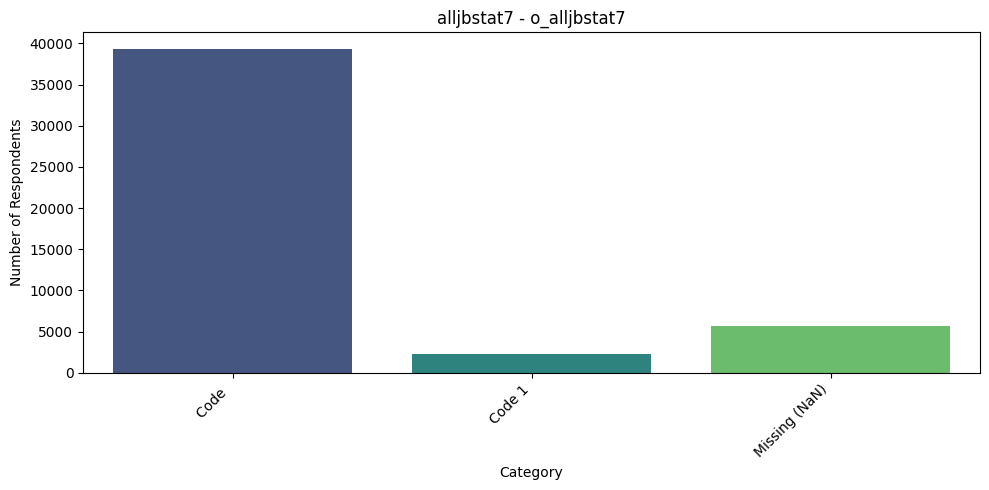

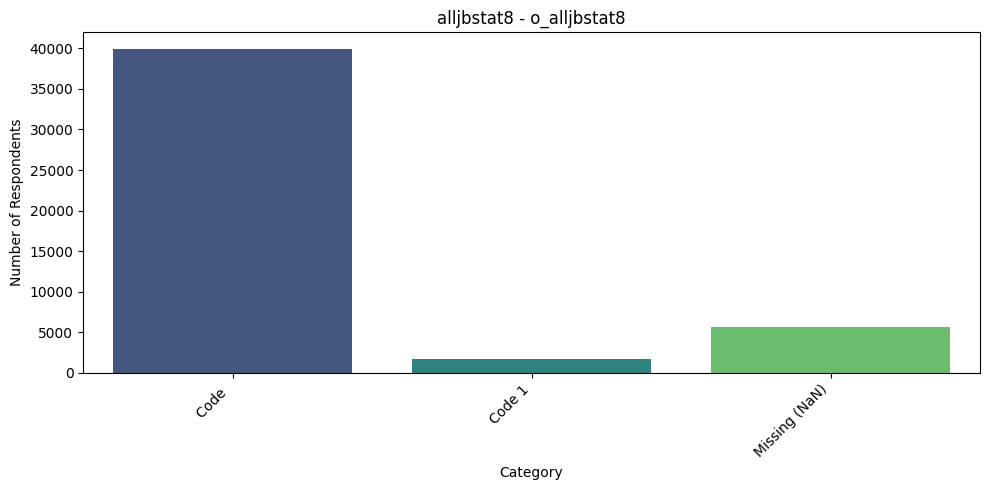

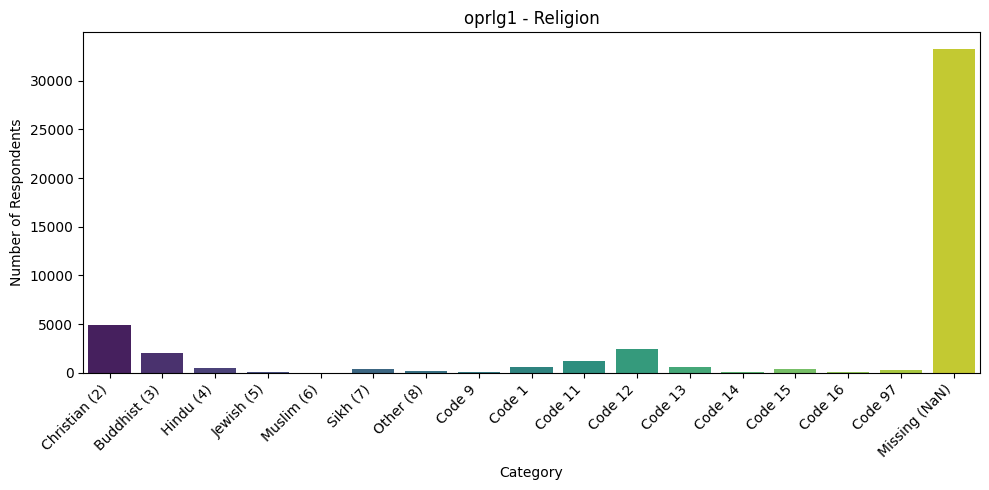

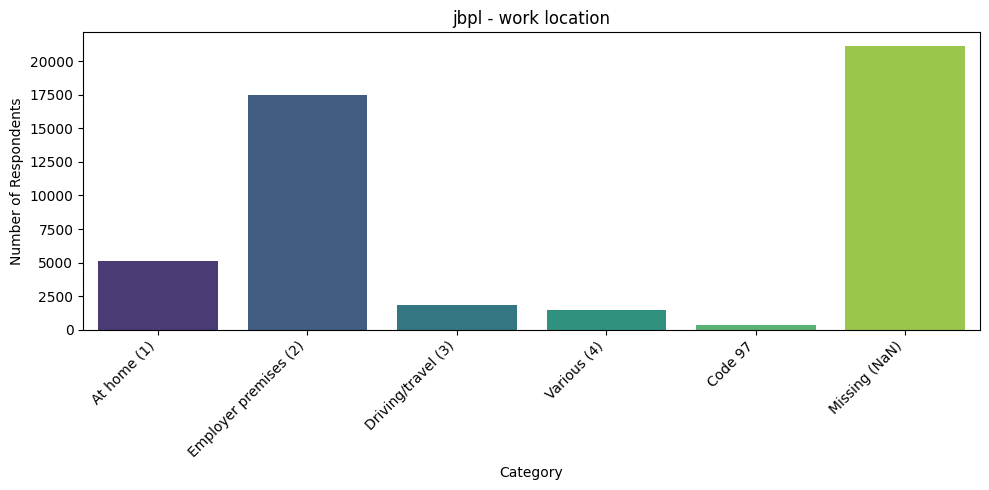

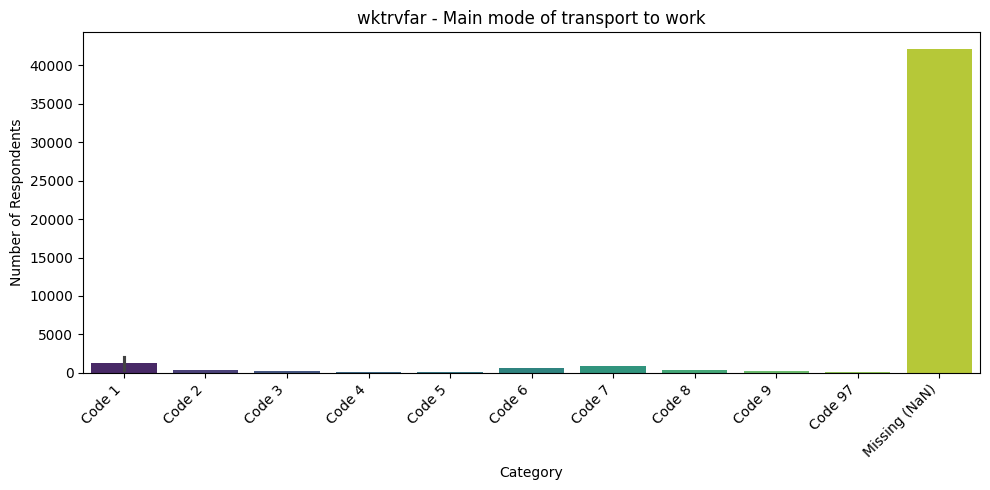

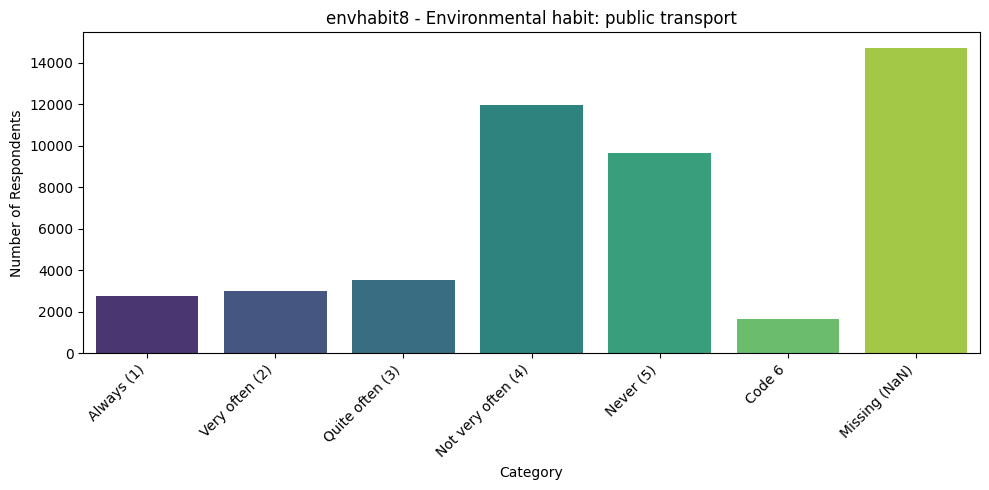

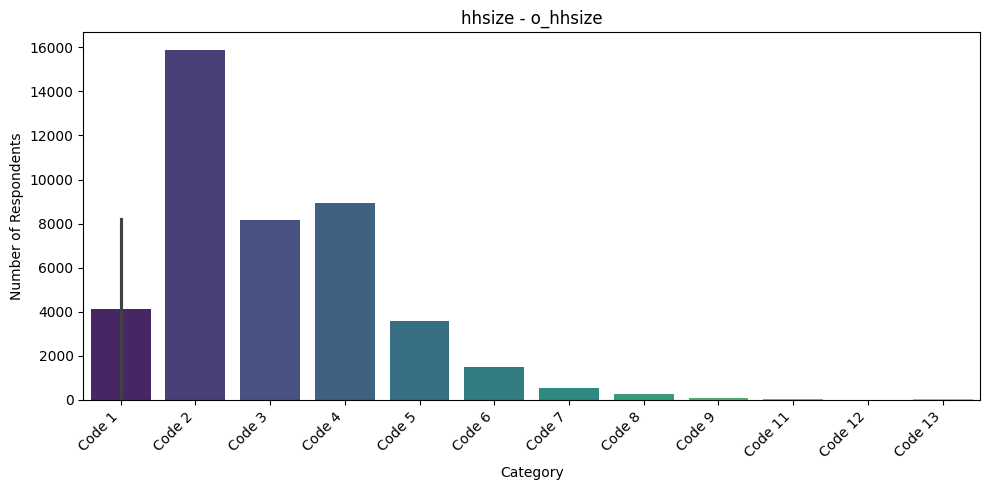

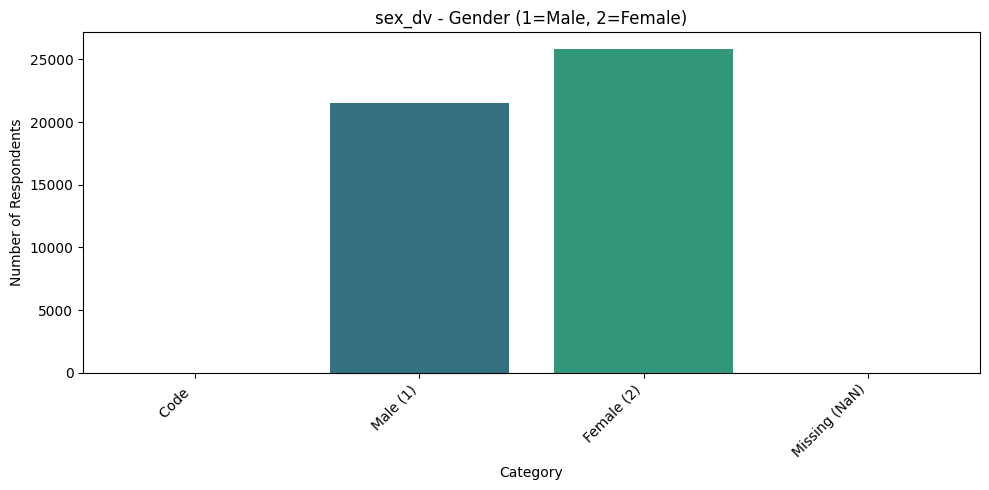

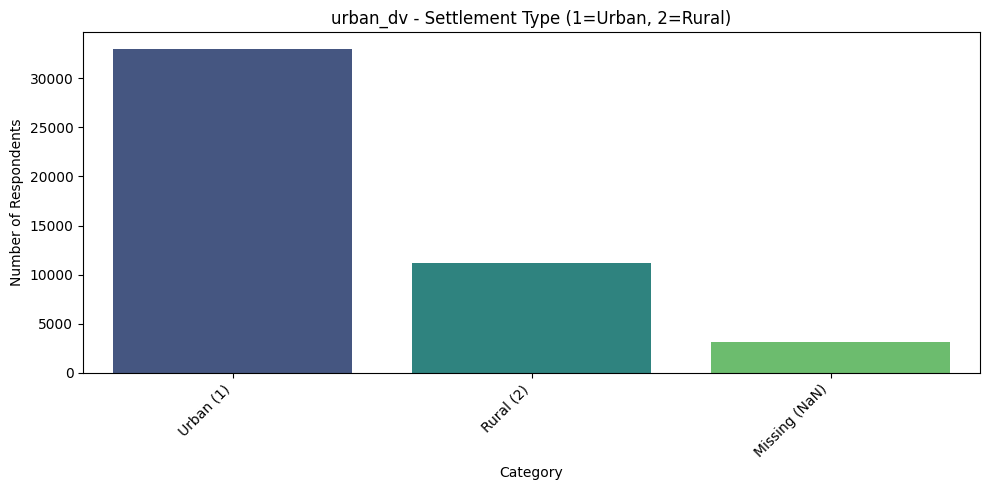

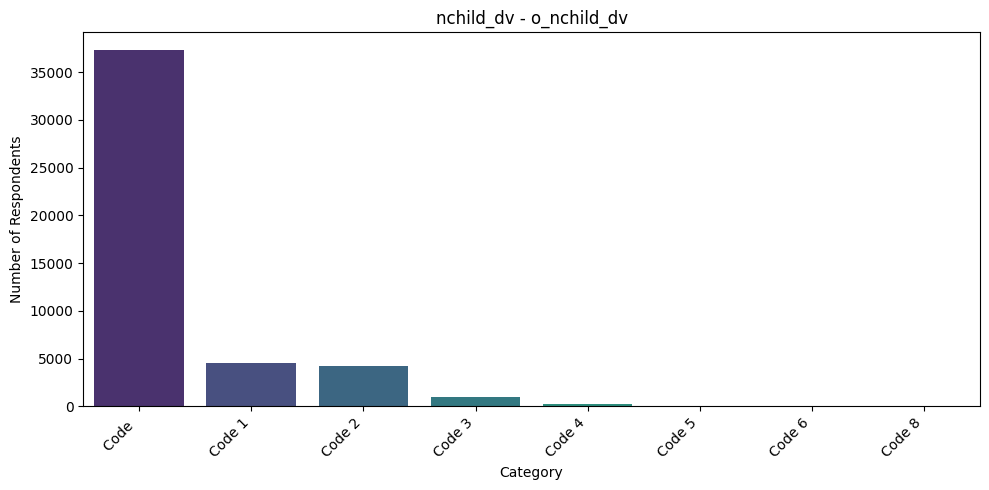

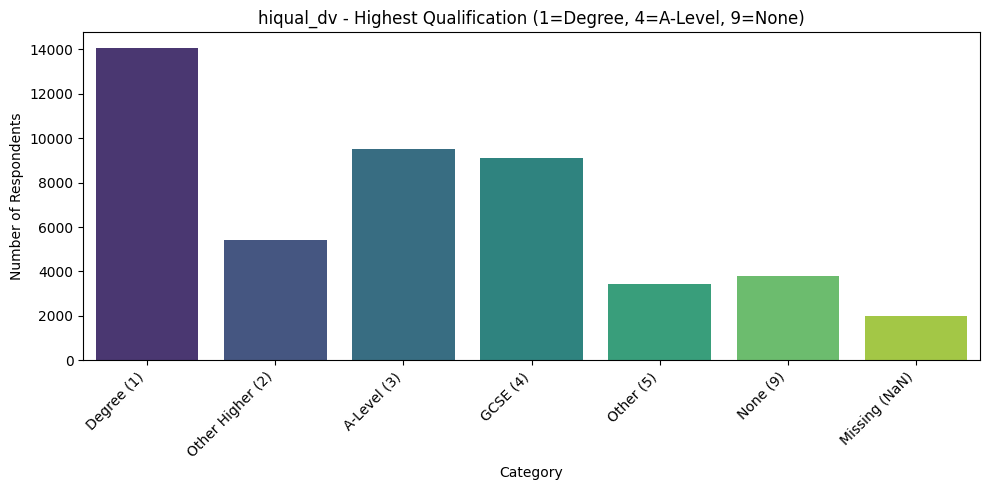

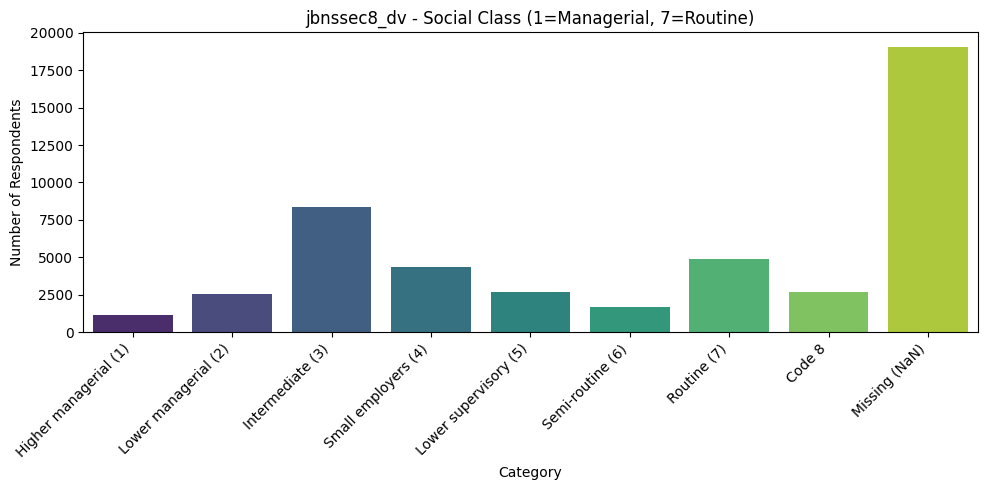

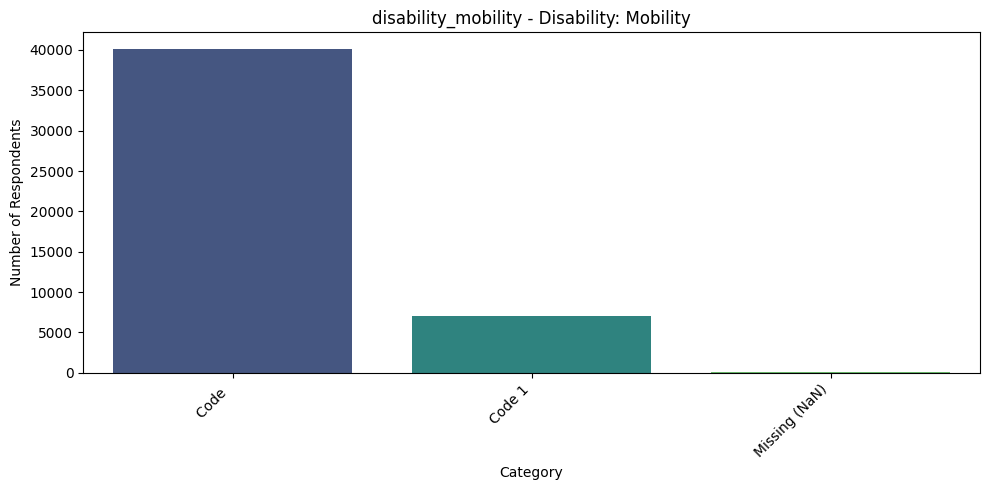

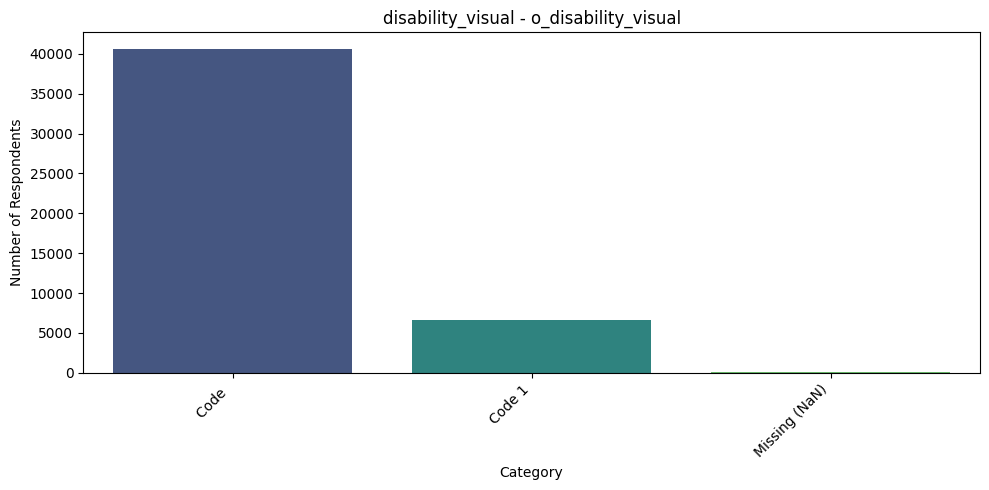

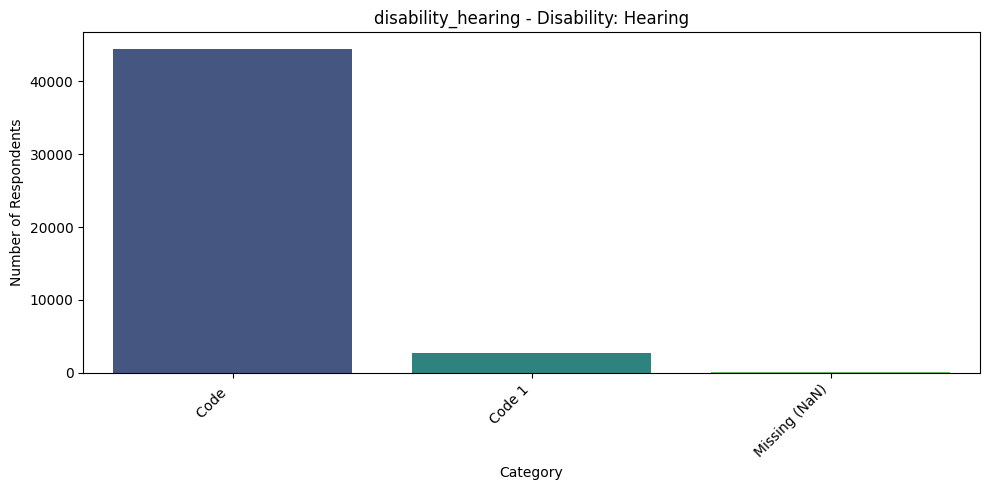

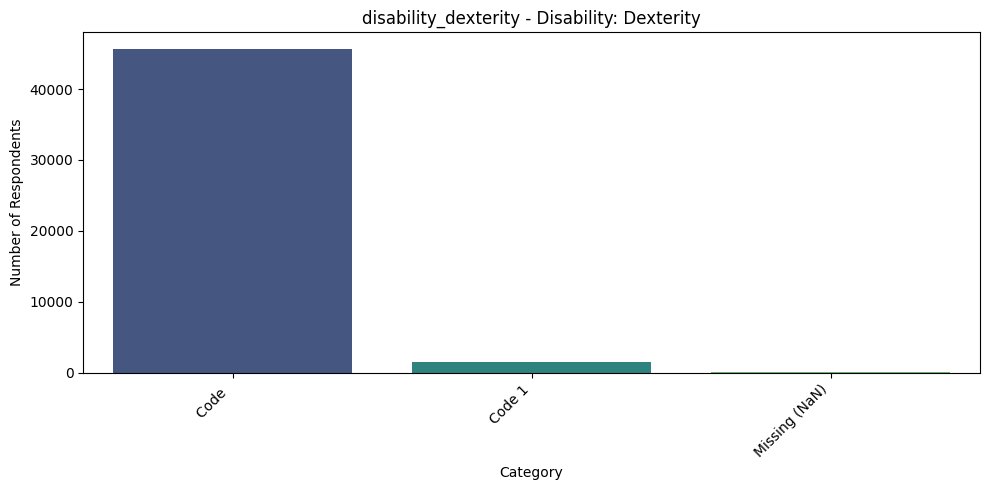

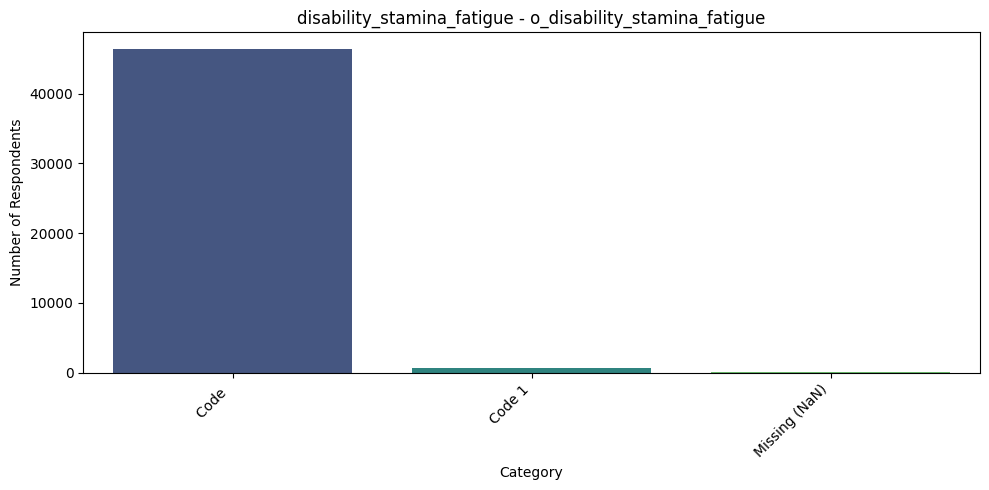

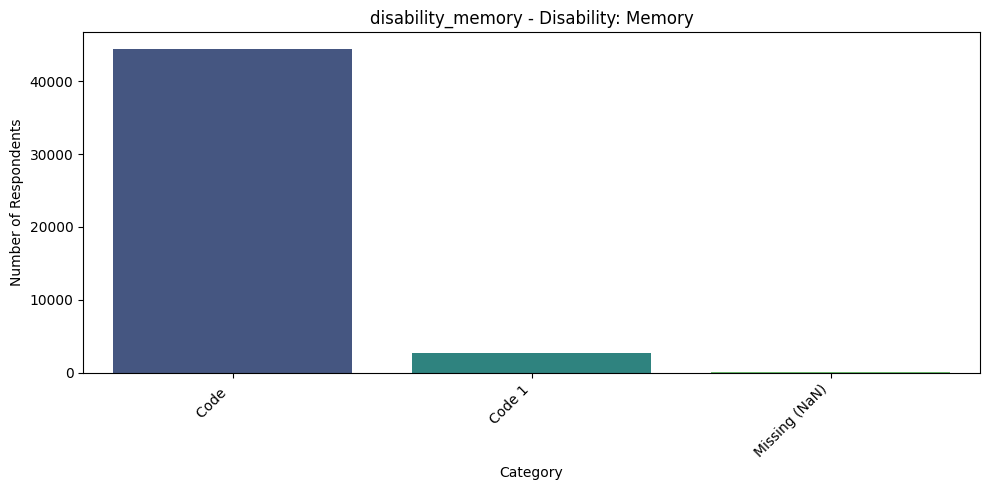

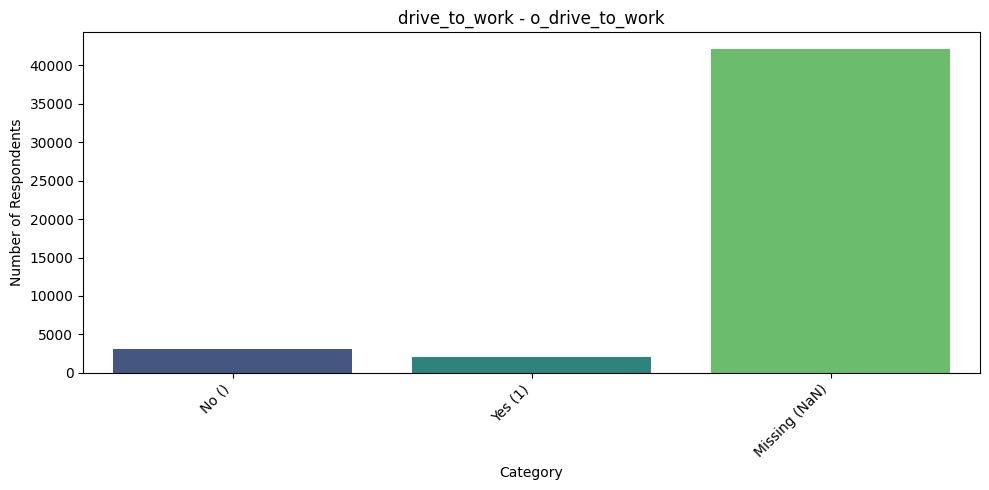

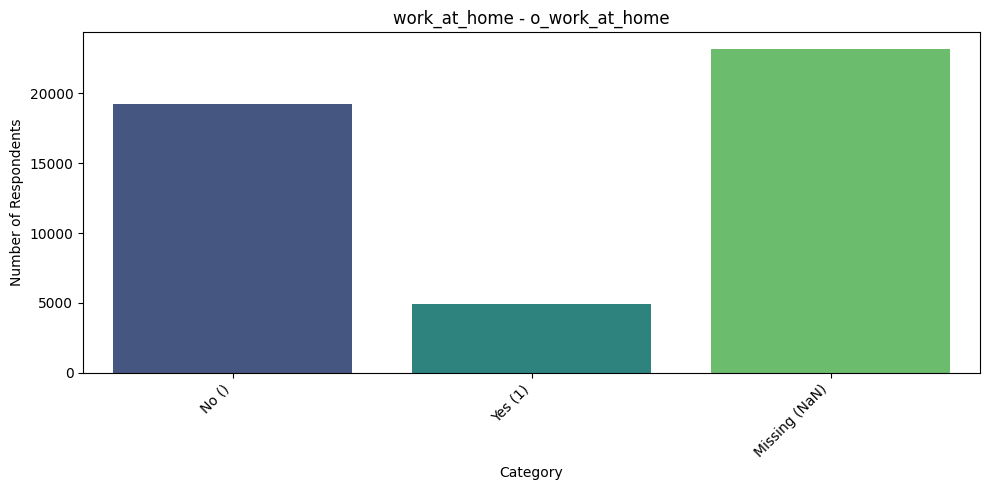

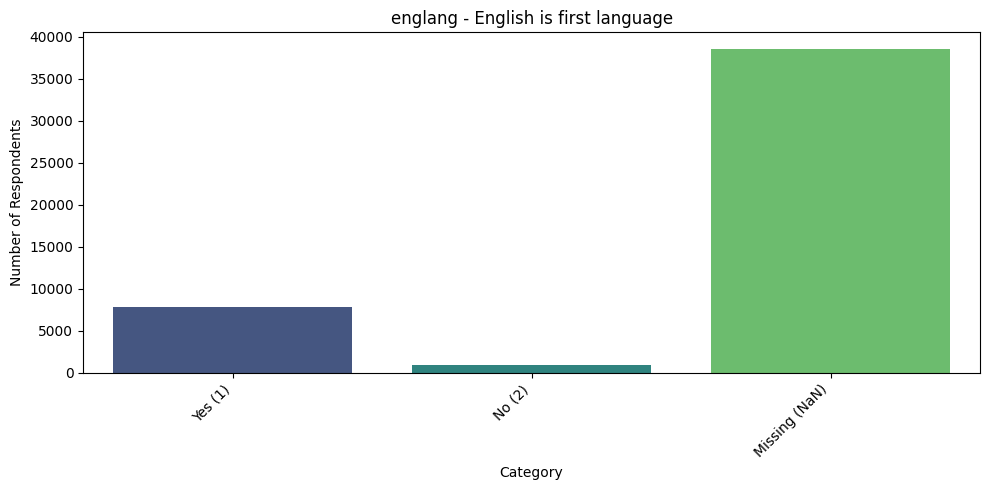

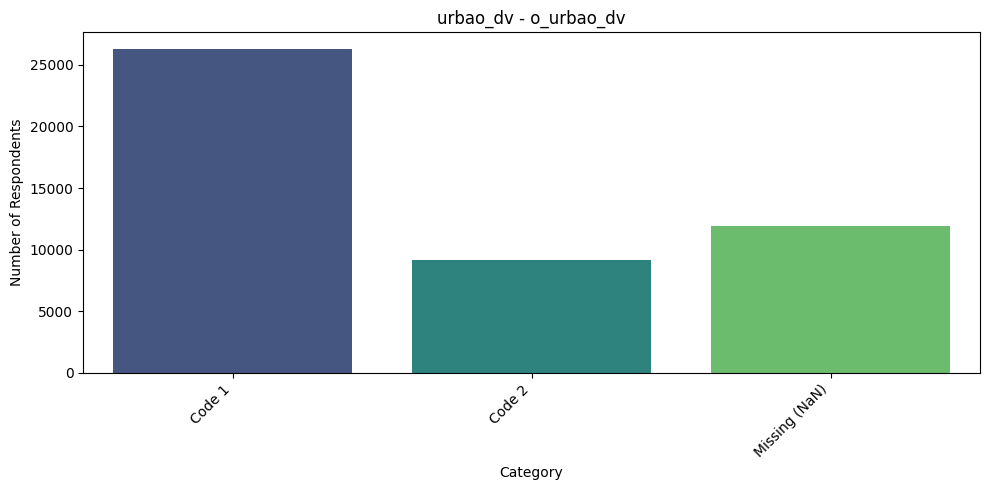

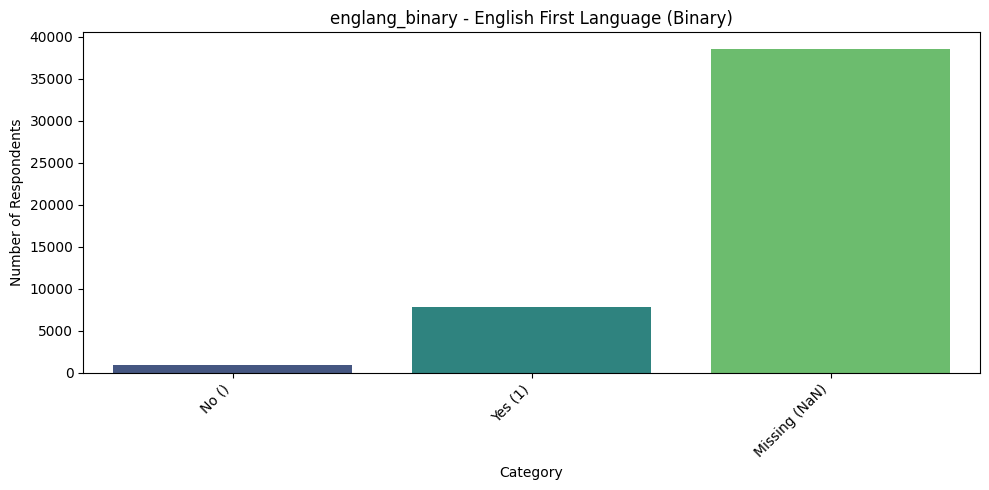

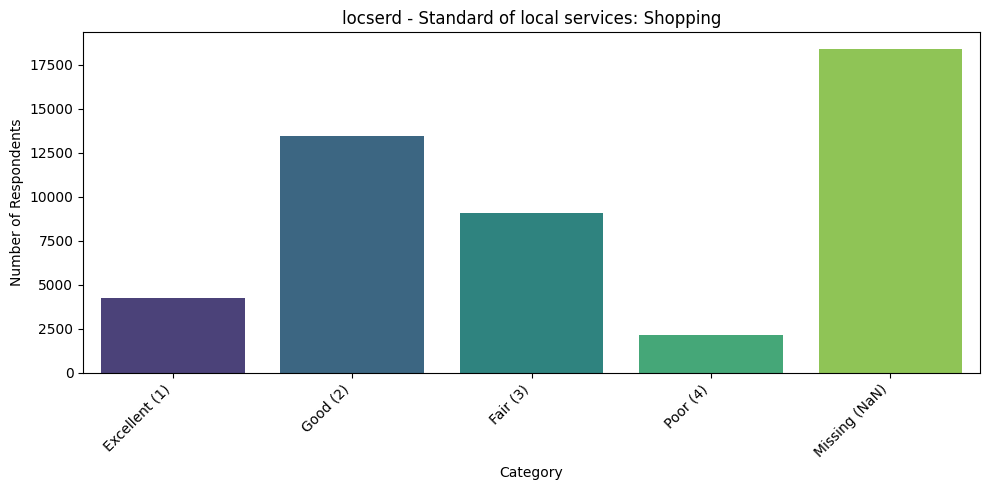

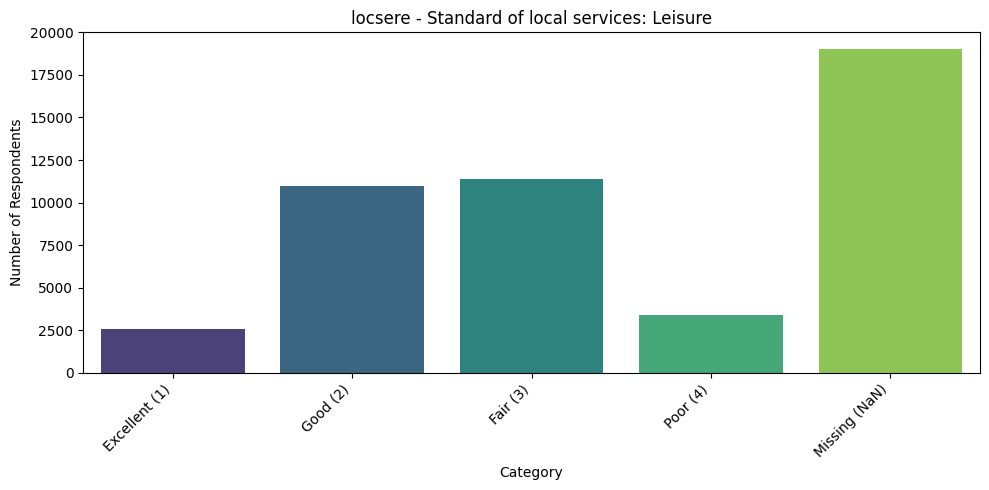

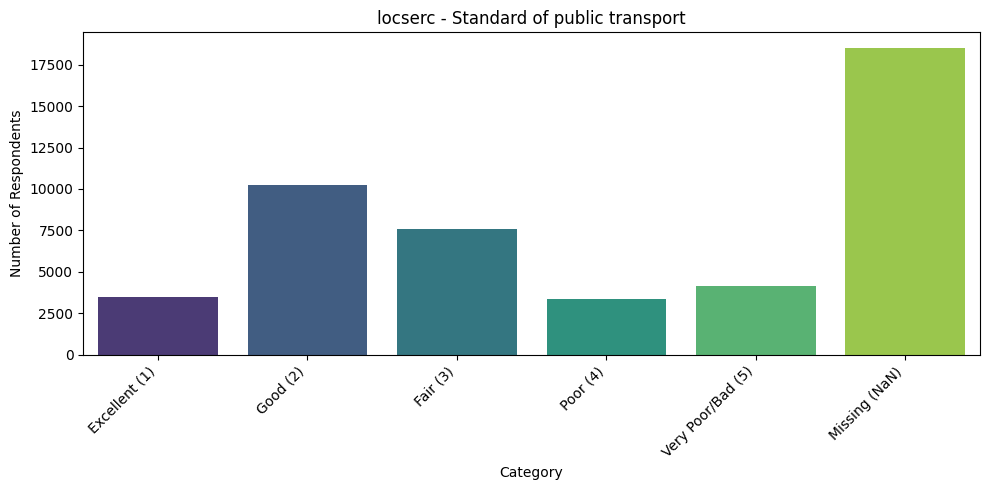

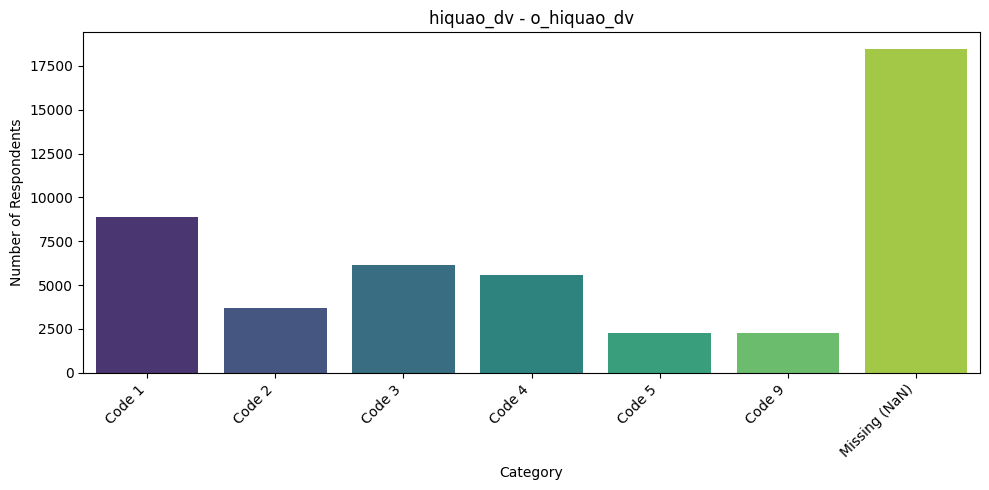

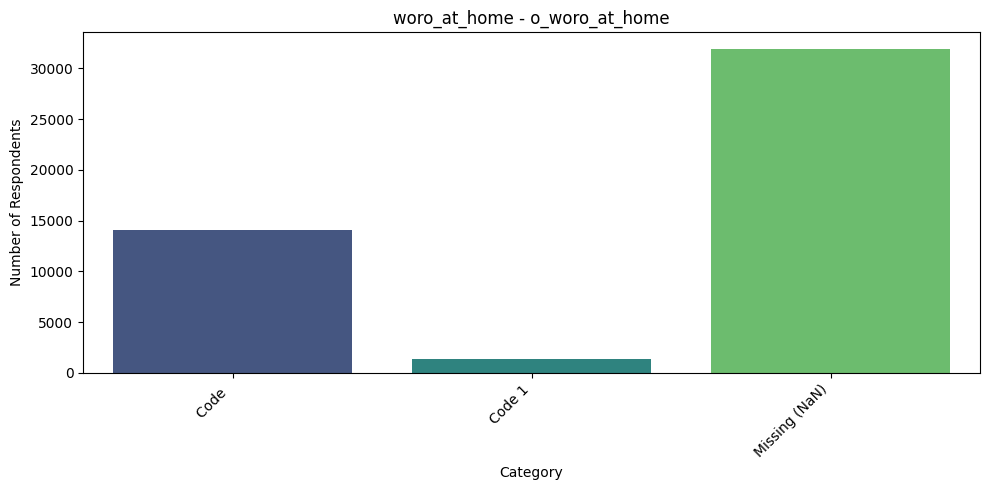

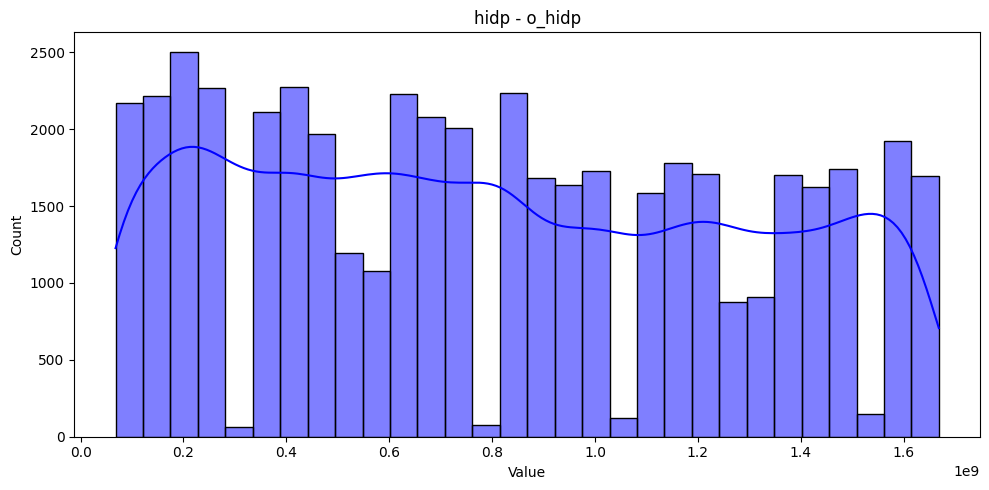

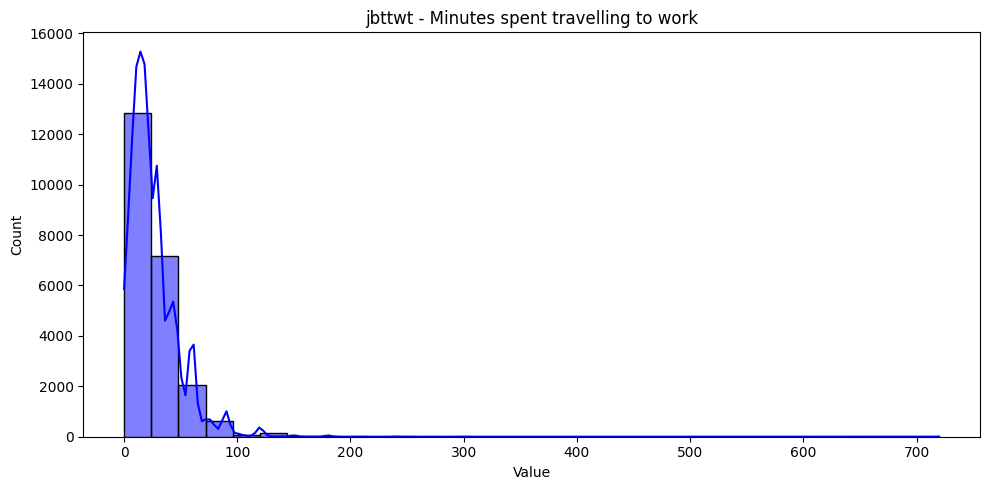

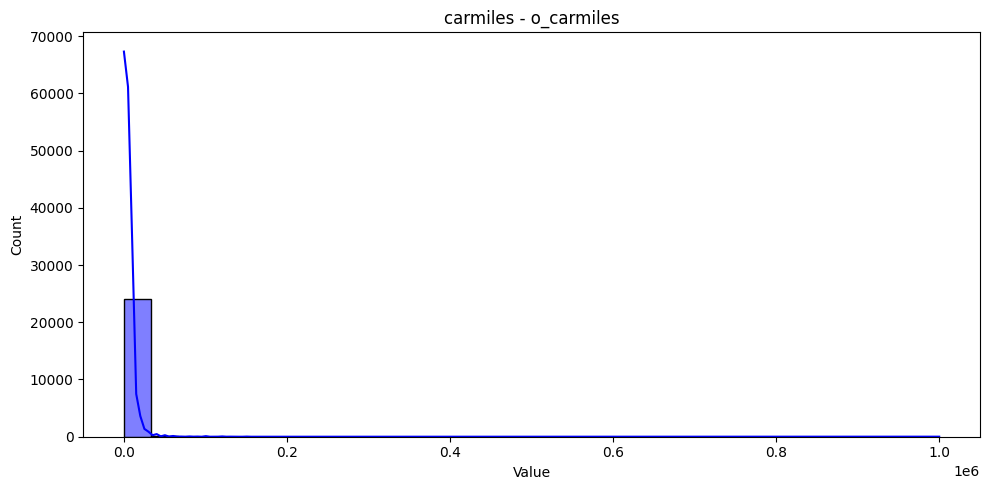

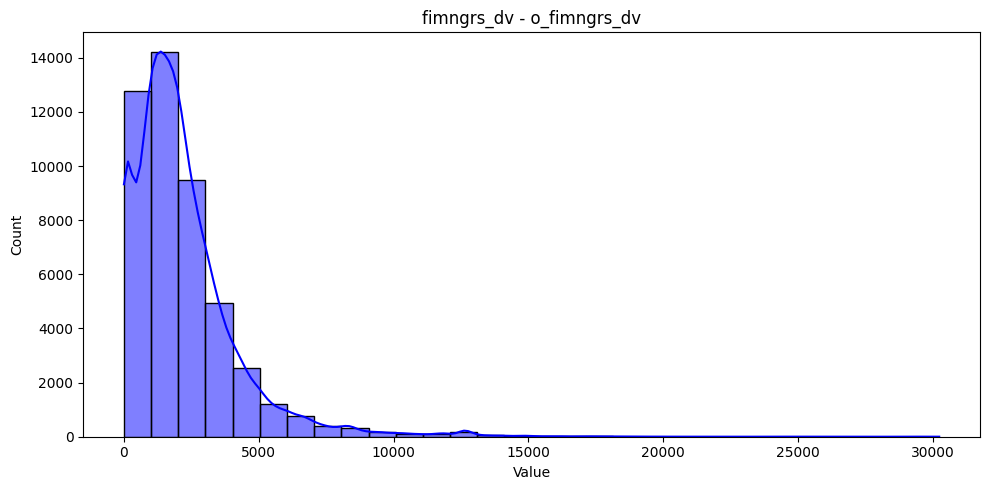

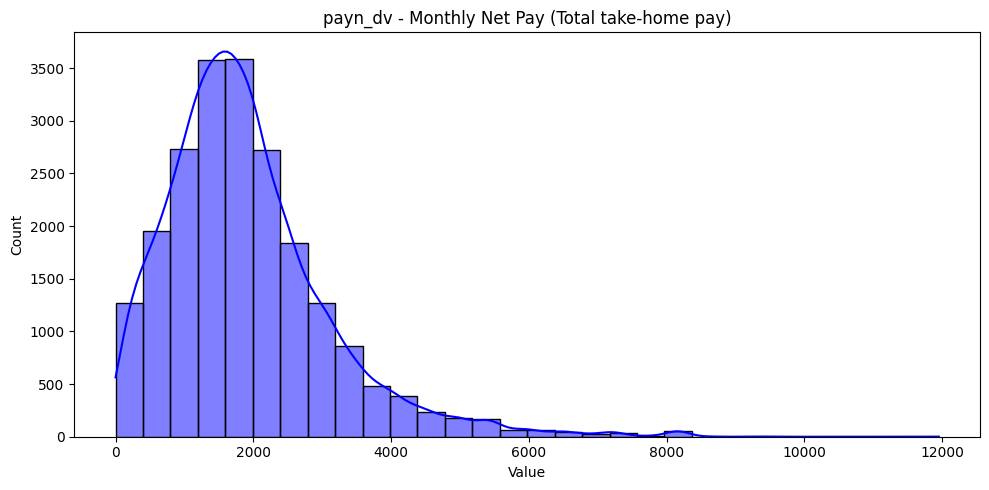

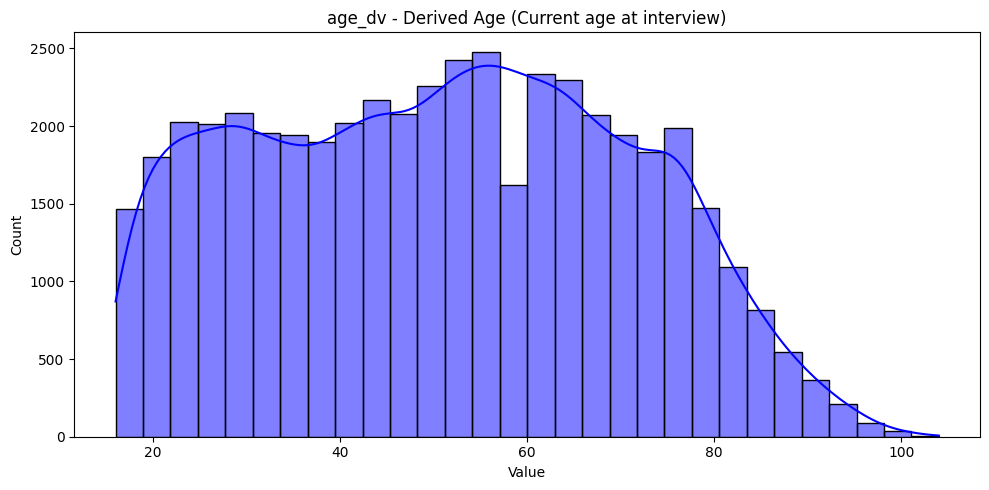

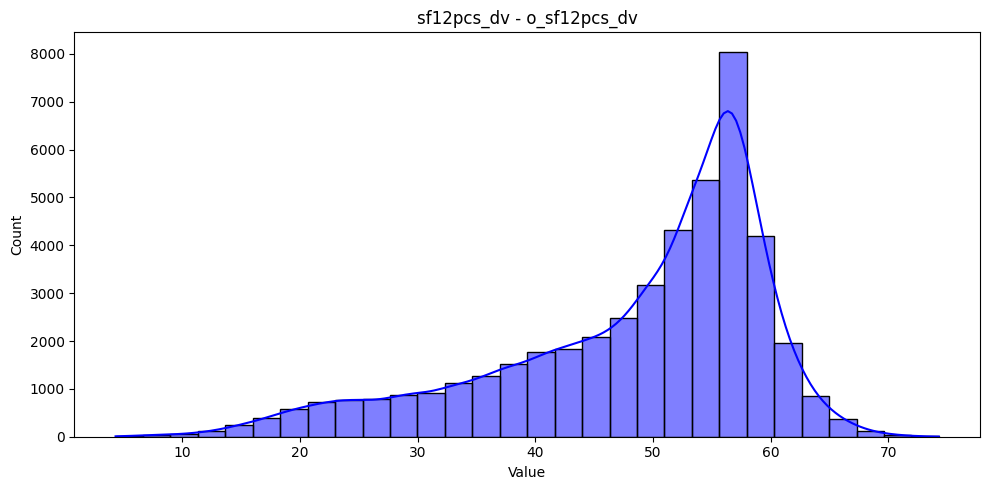

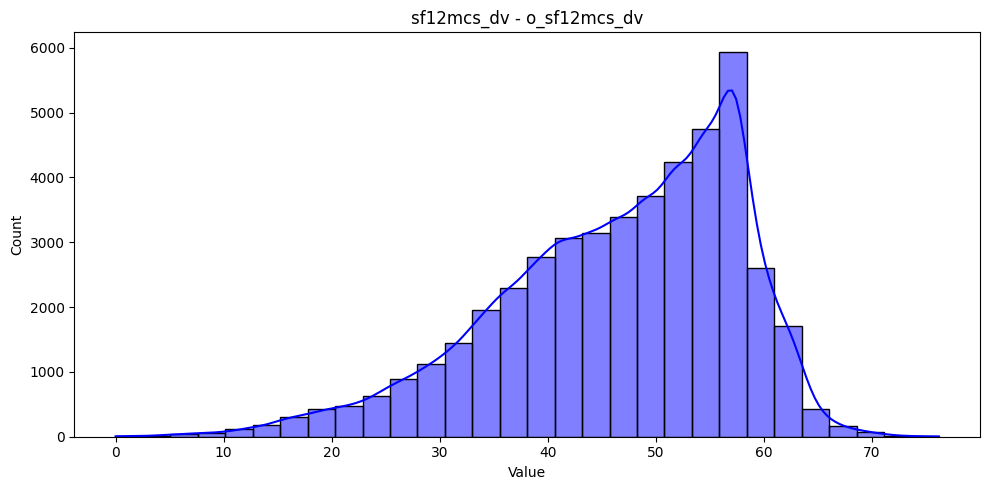

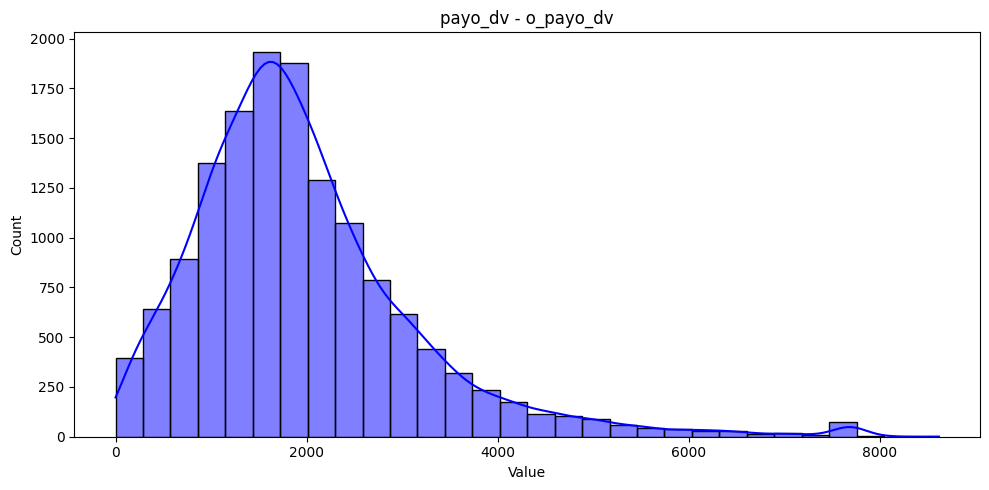

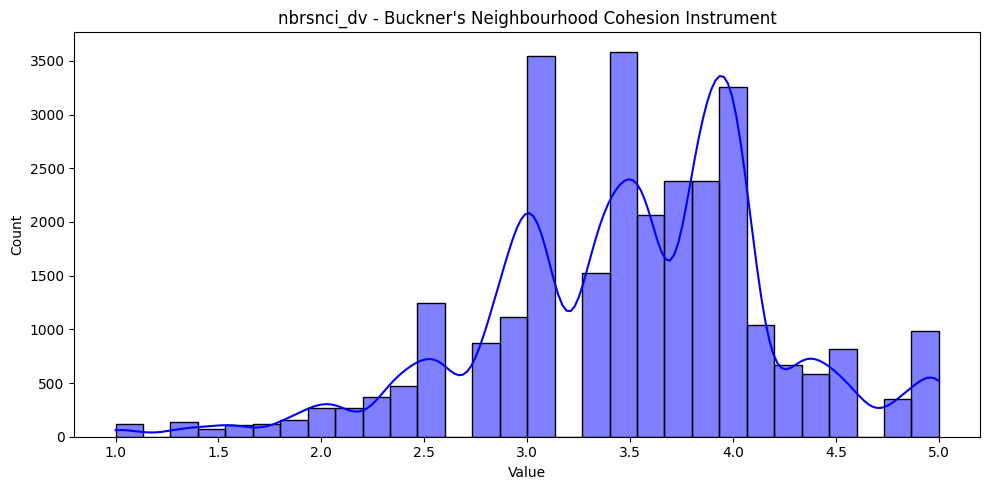

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from ukhls_variables import VARIABLE_MAP, CATEGORY_MAPS

warnings.filterwarnings('ignore')

# --- FILE PATHS ---
INPUT_PKL = "../data/ukhls/pickles/o_indresp_backfilled.pkl"

# Load the data
print(f"Loading {INPUT_PKL}...")
df = pd.read_pickle(INPUT_PKL)
print(f"Dataset shape: {df.shape}")

# Add the 'o_' prefix expected by the dataframe columns
# Both for descriptions and categorical maps
notebook_category_maps = {}
for var_name, mapping in CATEGORY_MAPS.items():
    notebook_category_maps[f"o_{var_name}"] = mapping

notebook_var_descriptions = {}
for var_name, desc in VARIABLE_MAP.items():
    notebook_var_descriptions[f"o_{var_name}"] = desc

# Add specific binary/engineered variables that might not be in VARIABLE_MAP explicitly with exact names
notebook_var_descriptions.update({
    'o_englang_binary': 'English First Language (Binary)',
    'o_disability_mobility': 'Disability: Mobility',
    'o_disability_memory': 'Disability: Memory',
    'o_disability_dexterity': 'Disability: Dexterity',
    'o_disability_learning': 'Disability: Learning',
    'o_disability_vision': 'Disability: Vision',
    'o_disability_hearing': 'Disability: Hearing'
})

# Split into categorical and continuous heuristically
categorical_cols = []
continuous_cols = []

for col in df.columns:
    if col == 'pidp' or col == 'tribe_id':
        continue
        
    if df[col].nunique() < 20:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Found {len(categorical_cols)} categorical variables and {len(continuous_cols)} continuous variables.\n")

# Plot Categorical Variables
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Get value counts including NaNs
    counts = df[col].value_counts(dropna=False).sort_index()
    
    # Map the index to English labels, appending the original code
    labels = []
    for val in counts.index:
        if pd.isna(val):
            labels.append("Missing (NaN)")
        else:
            code_str = str(val).rstrip('.0') if str(val).endswith('.0') else str(val)
            # Cast val to float to avoid numpy typing mapping misses
            try:
                lookup_val = float(val)
            except (ValueError, TypeError):
                lookup_val = val
                
            if col in notebook_category_maps and lookup_val in notebook_category_maps[col]:
                labels.append(f"{notebook_category_maps[col][lookup_val]} ({code_str})")
            else:
                labels.append(f"Code {code_str}")
                
    title_suffix = notebook_var_descriptions.get(col, col)
    
    sns.barplot(x=labels, y=counts.values, palette="viridis")
    
    # Strip wave prefix "o_" for clean chart titles 
    base_col = col[2:] if col.startswith("o_") else col
    
    plt.title(f"{base_col} - {title_suffix}")
    plt.xlabel("Category")
    plt.ylabel("Number of Respondents")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Plot Continuous Variables
for col in continuous_cols:
    plt.figure(figsize=(10, 5))
    
    valid_data = df[col].dropna()
    title_suffix = notebook_var_descriptions.get(col, col)
    
    # Replaced kdeplot with a much more legible histogram
    sns.histplot(valid_data, bins=30, color="blue", kde=True)
    
    # Strip wave prefix "o_" for clean chart titles 
    base_col = col[2:] if col.startswith("o_") else col
    
    plt.title(f"{base_col} - {title_suffix}")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()